# CTA bus ridership — exploration

Companion to `frequent_network_analysis.ipynb`, which is being rebuilt. This notebook is the
**exploration** step: understand the data and the system as a whole *before* designing any
before/after comparison.

### Ground rules

- Every filter or transformation happens in a visible cell and prints what it did.
- Nothing is dropped silently. Checks print their counts **even when the count is zero**.
- Aggregate at **week** level wherever possible; month only where a week is too short a window.

### Decisions agreed so far

| Decision | Choice |
|---|---|
| Week definition | **Mon–Sun (ISO)**, labelled by the Monday that starts it |
| Day of week | Derived from `date` itself, **not** from `daytype` |
| Role of `daytype` | Only to identify CTA-designated holidays |
| Partial weeks | **Kept and flagged**, never dropped |
| Control group (later) | All corridors outside the 20 — a starting point, held as a parameter |

### Still open

- How express / branch routes (`X49`, `53A`, …) fold into corridors.
- Before/after window lengths for the event study.
- The definition of "usual" used in the holiday section below — flagged inline.

## 0. Load and inventory

No filtering happens in this section. It reads the file and counts what is in it.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

# Okabe-Ito: the published colour-vision-deficiency-safe categorical set.
BLUE, ORANGE, GREEN, PURPLE = '#0072B2', '#D55E00', '#009E73', '#CC79A7'
GRAY, INK = '#C9C9C9', '#333333'

# Ridership regimes. 2020 gets its own colour because it is not comparable to anything
# else; the two recovery eras are lighter shades of it because the system has not
# returned to the pre-2020 level.
ERAS = [('pre-2020',     2001, 2019, BLUE),
        ('2020',         2020, 2020, ORANGE),
        ('2021-2022',    2021, 2022, '#EE8A4E'),
        ('2023-present', 2023, 2026, '#F5BE99')]
ERA_ORDER = [e[0] for e in ERAS]
ERA_COLOR = {e[0]: e[3] for e in ERAS}

def era(year):
    """Map a calendar year to its ridership regime."""
    for name, lo, hi, _ in ERAS:
        if lo <= year <= hi:
            return name
    return None

plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#9A9A9A', 'axes.grid': True,
    'grid.color': '#E8E8E8', 'grid.linewidth': 0.8,
})
fmt_riders = FuncFormatter(lambda v, _: f'{v*1e-6:.1f}M' if v >= 1e6 else f'{v*1e-3:.0f}k')

RAW = pd.read_csv('data/cta_bus_daily.csv', dtype={'route': str, 'daytype': str})
print(f'rows read : {len(RAW):,}')
print(f'columns   : {list(RAW.columns)}')
RAW.head()

rows read : 1,113,495
columns   : ['route', 'date', 'daytype', 'rides']


,route,date,daytype,rides
0,1,2001-01-02T00:00:00.000,W,5813
1,1,2001-01-03T00:00:00.000,W,6809
2,1,2001-01-04T00:00:00.000,W,6907
3,1,2001-01-05T00:00:00.000,W,6154
4,1,2001-01-08T00:00:00.000,W,6126


In [2]:
# ---------------------------------------------------------------------------
# INTEGRITY REPORT.  This cell drops nothing.  It only counts.
# ---------------------------------------------------------------------------
d = RAW.copy()
d['date']  = pd.to_datetime(d.date,  errors='coerce')
d['rides'] = pd.to_numeric(d.rides, errors='coerce')

for label, n in {
    'rows':                len(d),
    'unparseable dates':   int(d.date.isna().sum()),
    'non-numeric rides':   int(d.rides.isna().sum()),
    'rides < 0':           int((d.rides < 0).sum()),
    'rides == 0':          int((d.rides == 0).sum()),
    'null route':          int(d.route.isna().sum()),
    'null daytype':        int(d.daytype.isna().sum()),
}.items():
    print(f'{label:<28}: {n:>10,}')

print()
print(f'{"date range":<28}: {d.date.min().date()} .. {d.date.max().date()}')
print(f'{"distinct routes":<28}: {d.route.nunique():>10,}')
print(f'{"daytype values":<28}: {sorted(d.daytype.dropna().unique())}')

dup = d.duplicated(subset=['route', 'date'], keep=False)
print(f'{"duplicate (route,date) rows":<28}: {int(dup.sum()):>10,}')
if dup.any():
    g = d.loc[dup].groupby(['route', 'date'])
    print(f'{"  affected route-days":<28}: {g.ngroups:>10,}')
    print(f'{"  identical rides in dup":<28}: {int((g.rides.nunique() == 1).sum()):>10,}')
    display(d.loc[dup].sort_values(['route', 'date']).head(20))
    print(f'  (showing up to 20 of {int(dup.sum()):,} duplicate rows)')

rows                        :  1,113,495
unparseable dates           :          0
non-numeric rides           :          0
rides < 0                   :          0
rides == 0                  :         36
null route                  :          0
null daytype                :          0

date range                  : 2001-01-01 .. 2026-05-31
distinct routes             :        188
daytype values              : ['A', 'U', 'W']
duplicate (route,date) rows :          0


In [3]:
# Calendar coverage: is every day between the first and last date present?
days    = pd.date_range(d.date.min(), d.date.max(), freq='D')
missing = days.difference(pd.Index(d.date.unique()))
print(f'{"calendar days in range":<28}: {len(days):>10,}')
print(f'{"days with no rows at all":<28}: {len(missing):>10,}')
if len(missing):
    print('  ', [str(x.date()) for x in missing[:20]],
          f'... (showing up to 20 of {len(missing)})')

per_day = d.groupby('date').route.nunique()
print(f'\nroutes reporting per day:  min={per_day.min()}   '
      f'median={per_day.median():.0f}   max={per_day.max()}')

calendar days in range      :      9,282
days with no rows at all    :          0



routes reporting per day:  min=84   median=126   max=153


## 0b. Route names and corridors

The daily file has no route names, but its **monthly sibling** on the same portal does, along
with day-type averages we can check our own aggregation against:

[CTA – Ridership – Bus Routes – Monthly Day-Type Averages & Totals](https://data.cityofchicago.org/Transportation/CTA-Ridership-Bus-Routes-Monthly-Day-Type-Averages/bynn-gwxy)
(`bynn-gwxy`), saved to `data/cta_bus_monthly.csv`:

```
curl "https://data.cityofchicago.org/resource/bynn-gwxy.csv?$limit=50000&$order=route,month_beginning" \
     -o data/cta_bus_monthly.csv
```

Columns: `route`, `routename`, `month_beginning`, `avg_weekday_rides`, `avg_saturday_rides`,
`avg_sunday_holiday_rides`, `monthtotal`.

In [4]:
MON = pd.read_csv('data/cta_bus_monthly.csv', dtype={'route': str},
                  parse_dates=['month_beginning'])
print(f'rows {len(MON):,}   routes {MON.route.nunique()}   '
      f'{MON.month_beginning.min().date()} .. {MON.month_beginning.max().date()}')

# Names change over time, so take each route's most recent name and list the changes.
latest = MON.sort_values('month_beginning').groupby('route').routename.last()
changed = MON.groupby('route').routename.nunique()
changed = changed[changed > 1]
print(f'\nroutes renamed at least once: {len(changed)}')
for r in changed.index:
    print(f'  {r:<5} ' + ' -> '.join(MON.loc[MON.route == r, 'routename'].unique()))

print(f'\nin daily but not monthly (no name available): '
      f'{sorted(set(d.route) - set(MON.route))}')
print(f'in monthly but not daily: {sorted(set(MON.route) - set(d.route))}')

rows 41,140   routes 186   2001-01-01 .. 2026-05-01

routes renamed at least once: 11
  1     Indiana/Hyde Park -> Bronzeville/Union Station
  10    Museum of S & I -> Obama Presidential Center/Museum of Science & Industry Express
  11    Lincoln/Sedgwick -> Lincoln
  111   Pullman/111th/115th -> 111th/King Drive
  120   Ogilvie/Wacker Express -> Ogilvie/Streeterville Express
  121   Union/Wacker Express -> Union/Streeterville Express
  146   Inner Drive/Michigan Express -> Inner Lake Shore/Michigan Express
  147   Outer Drive Express -> Outer DuSable Lake Shore Express
  35    35th -> 31st/35th
  52    Kedzie/California -> Kedzie
  94    South California -> California



in daily but not monthly (no name available): ['137', '290S']
in monthly but not daily: []


**Corridor**, starting definition: routes sharing the same numeric root — so `49`, `X49`, `49B`
belong to corridor `49`, and `J14` to corridor `14`. This is a first cut, not a final answer;
branch and express routes do not always follow the same street, so the families printed below
are meant to be audited one at a time before any of them are actually summed.

In [5]:
import re

def corridor(route):
    """Numeric root of a route id: X49 -> 49, J14 -> 14, 1001 -> 1001."""
    m = re.search(r'\d+', route)
    return m.group() if m else route

d['name']     = d.route.map(latest)
d['corridor'] = d.route.map(corridor)

size = d.groupby('route').rides.mean()
fam  = (d.groupby('corridor').route.unique()
          .loc[lambda s: s.map(len) > 1]
          .sort_index(key=lambda i: i.astype(int)))

print(f'corridors: {d.corridor.nunique()}   of which multi-route: {len(fam)}')
print('Read this list critically -- some of these are one street, others are not.\n')
for cor, routes in fam.items():
    print(f'  corridor {cor}')
    for r in sorted(routes, key=lambda x: -size[x]):
        print(f'      {r:<6} {size[r]:>8,.0f}/day   {latest.get(r, "(no name)")}')

corridors: 146   of which multi-route: 30
Read this list critically -- some of these are one street, others are not.

  corridor 3
      3        15,906/day   King Drive
      X3        1,926/day   King Drive Express
  corridor 4
      4        17,181/day   Cottage Grove
      X4        2,235/day   Cottage Grove Express
  corridor 5
      5           392/day   South Shore Night Bus
      N5          160/day   South Shore Night Bus
  corridor 8
      8        16,321/day   Halsted
      8A        2,747/day   South Halsted
  corridor 9
      9        20,624/day   Ashland
      X9        7,154/day   Ashland Express
  corridor 14
      14       10,149/day   Jeffery Express
      J14       7,231/day   Jeffery Jump
  corridor 20
      20       15,164/day   Madison
      X20       2,146/day   Washington/Madison Express
  corridor 21
      21        7,120/day   Cermak
      X21       1,098/day   Cermak Express
  corridor 22
      22       16,070/day   Clark
      R22       2,648/day   Cermak-Ro

### Cross-check: does our daily aggregation reproduce the published monthly averages?

`daytype` `W` excludes holidays, so a month's mean over `W` days should equal the published
`avg_weekday_rides`. Any systematic gap would mean we are reading the day types wrongly.

In [6]:
ours = (d[d.daytype == 'W']
          .groupby(['route', pd.Grouper(key='date', freq='MS')]).rides.mean()
          .rename('ours').reset_index()
          .rename(columns={'date': 'month_beginning'}))

chk = ours.merge(MON[['route', 'month_beginning', 'avg_weekday_rides']],
                 on=['route', 'month_beginning'], how='inner')
chk['diff_pct'] = (chk.ours - chk.avg_weekday_rides) / chk.avg_weekday_rides * 100

print(f'month-route pairs compared : {len(chk):,}')
print(f'  exact to within 0.5%     : {int((chk.diff_pct.abs() < 0.5).sum()):,}')
print(f'  median |difference|      : {chk.diff_pct.abs().median():.3f}%')
print(f'  worst |difference|       : {chk.diff_pct.abs().max():.2f}%')
print('\nlargest disagreements:')
print(chk.reindex(chk.diff_pct.abs().sort_values(ascending=False).index)
         .head(8)[['route', 'month_beginning', 'ours', 'avg_weekday_rides', 'diff_pct']]
         .to_string(index=False))

month-route pairs compared : 40,842
  exact to within 0.5%     : 40,691
  median |difference|      : 0.001%
  worst |difference|       : 15.15%

largest disagreements:
route month_beginning     ours  avg_weekday_rides  diff_pct
  130      2025-01-01 1.727273                1.5 15.151515
  130      2025-03-01 1.952381                1.8  8.465608
  992      2020-05-01 1.400000                1.5 -6.666667
 1001      2010-03-01 3.000000                3.2 -6.250000
  992      2020-06-01 0.750000                0.8 -6.250000
  154      2001-07-01 2.000000                2.1 -4.761905
  154      2016-03-01 2.000000                2.1 -4.761905
 1001      2012-11-01 2.000000                2.1 -4.761905


## 1. Weeks

Weeks are **Mon–Sun**, labelled by the Monday that starts them, derived from `date` alone.
Each week carries `days` = how many distinct calendar days actually appear in the data, so a
short week at either end of the record is visible rather than silently reading as a dip.

In [7]:
d['week'] = d.date - pd.to_timedelta(d.date.dt.weekday, unit='D')
d['dow']  = d.date.dt.dayofweek                 # 0=Mon .. 6=Sun, from the date itself
DOW = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

wk = (d.groupby('week')
        .agg(rides=('rides', 'sum'), days=('date', 'nunique'), routes=('route', 'nunique'))
        .reset_index())
wk['partial'] = wk.days < 7

print(f'weeks spanned            : {len(wk):,}')
print(f'partial weeks (<7 days)  : {int(wk.partial.sum())}')
print()
print(wk[wk.partial].to_string(index=False))

weeks spanned            : 1,326
partial weeks (<7 days)  : 0

Empty DataFrame
Columns: [week, rides, days, routes, partial]
Index: []


## 2. Total ridership by week, whole dataset

The lower panel is the number of routes reporting that week. The system total is a sum over a
route set that changes over time, so the two have to be read together.

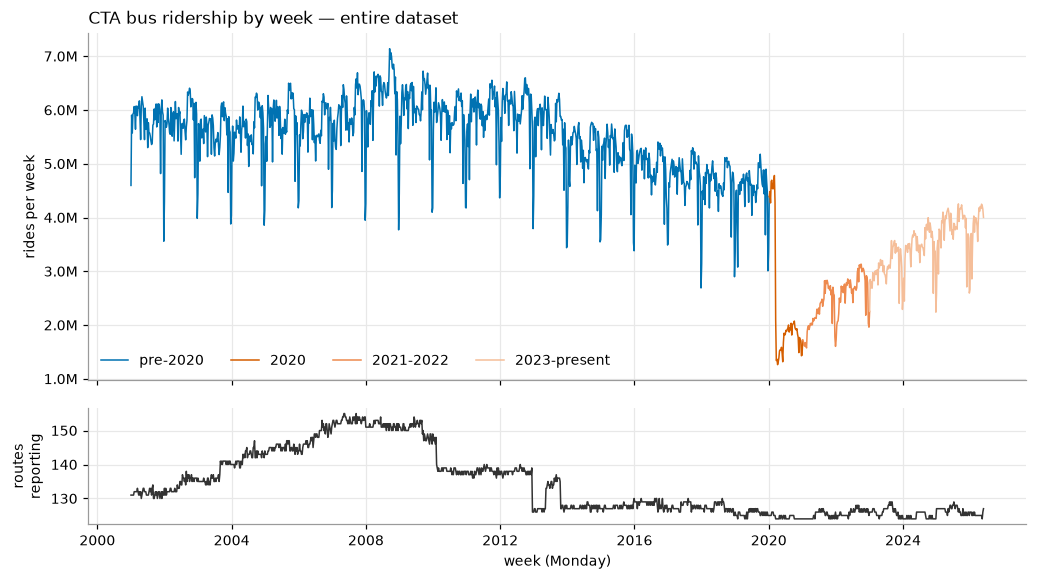

In [8]:
wk['era'] = wk.week.dt.year.map(era)

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(11, 5.8), sharey=False, sharex=True,
                              gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.12})

# Eras are contiguous in time, so extend each slice by one week to close the seams.
for name in ERA_ORDER:
    idx = np.flatnonzero((wk.era == name).to_numpy())
    sl = slice(idx[0], idx[-1] + 2)
    ax.plot(wk.week[sl], wk.rides[sl], lw=1.0, color=ERA_COLOR[name], label=name)

ax.set_ylabel('rides per week')
ax.yaxis.set_major_formatter(fmt_riders)
ax.set_title('CTA bus ridership by week — entire dataset', loc='left', fontsize=11)
ax.legend(frameon=False, loc='lower left', ncol=4)

# Only draw the partial-week marker if there are any; the count is printed above either way.
if wk.partial.any():
    ax.scatter(wk.loc[wk.partial, 'week'], wk.loc[wk.partial, 'rides'],
               s=30, color=PURPLE, zorder=3, label='partial week (<7 days of data)')

ax2.plot(wk.week, wk.routes, lw=1.0, color=INK)
ax2.set_ylabel('routes\nreporting')
ax2.set_xlabel('week (Monday)')
plt.show()

## 3. Individual routes by week

Every route in the dataset, one line each. The 20 Frequent Network routes are highlighted.

Log scale, because route sizes span orders of magnitude. Nothing is excluded.

> **Note.** Only the 20 route IDs as CTA labels them are highlighted. Their express / branch
> variants (`X49`, `53A`, …) are drawn in grey with everything else, because the corridor
> question is still open.

In [9]:
FREQ = ['J14', '4', '9', '12', '20', '34', '47', '49', '53', '54',
        '55', '60', '63', '66', '72', '77', '79', '81', '82', '95']

in_data = set(d.route.unique())
present = [r for r in FREQ if r in in_data]
print(f'Frequent Network routes (CTA labelling) : {len(FREQ)}')
print(f'  found in the data                     : {len(present)}')
print(f'  NOT found in the data                 : {[r for r in FREQ if r not in in_data]}')

rw = d.pivot_table(index='week', columns='route', values='rides', aggfunc='sum')
print(f'\nroute x week matrix: {rw.shape[0]:,} weeks x {rw.shape[1]:,} routes')
print(f'empty cells (route not reporting that week): {int(rw.isna().sum().sum()):,}'
      f'  of {rw.size:,}')

Frequent Network routes (CTA labelling) : 20
  found in the data                     : 20
  NOT found in the data                 : []

route x week matrix: 1,326 weeks x 188 routes
empty cells (route not reporting that week): 71,565  of 249,288


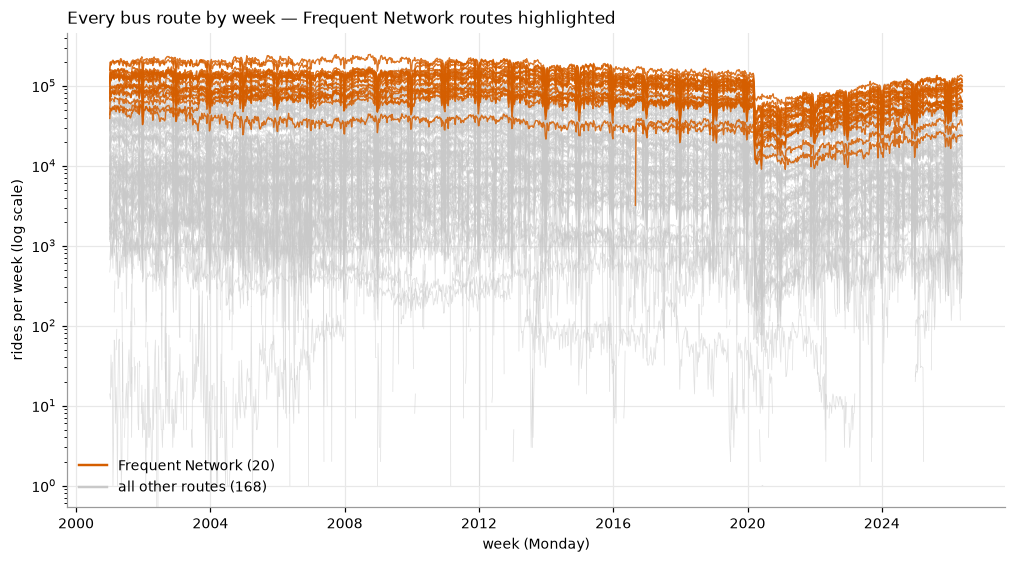

In [10]:
others = [r for r in rw.columns if r not in present]

fig, ax = plt.subplots(figsize=(11, 5.6))
ax.plot(rw.index, rw[others],  lw=0.5, color=GRAY,   alpha=0.55)
ax.plot(rw.index, rw[present], lw=0.9, color=ORANGE, alpha=0.85)
ax.set_yscale('log')
ax.set_ylabel('rides per week (log scale)')
ax.set_xlabel('week (Monday)')
ax.set_title('Every bus route by week — Frequent Network routes highlighted',
             loc='left', fontsize=11)
ax.legend(handles=[Line2D([], [], color=ORANGE, lw=1.6, label=f'Frequent Network ({len(present)})'),
                   Line2D([], [], color=GRAY,   lw=1.6, label=f'all other routes ({len(others)})')],
          frameon=False, loc='lower left')
plt.show()

### Route inventory and ridership statistics

Unit throughout is **riders per day** — the raw records are daily totals, so a route's mean is
its mean over the days it reported. Weekdays, Saturdays and Sundays are pooled here, so a
route's mean reflects its weekday/weekend mix as well as its size.

`status` marks routes that stopped reporting more than 30 days before the end of the data —
these are routes that were cut or renumbered. Nothing is filtered; all 188 routes are listed.

In [11]:
END = d.date.max()
g = d.groupby('route')

inv = pd.DataFrame({
    'name':     g.name.first(),
    'corridor': g.corridor.first(),
    'first':    g.date.min(),
    'last':     g.date.max(),
    'days':     g.date.nunique(),
    'mean':     g.rides.mean(),
    'median':   g.rides.median(),
    'std':      g.rides.std(),
    'min':      g.rides.min(),
    'max':      g.rides.max(),
})
inv['min_date'] = d.loc[g.rides.idxmin(), ['route', 'date']].set_index('route').date
inv['max_date'] = d.loc[g.rides.idxmax(), ['route', 'date']].set_index('route').date
inv['status']   = np.where(inv['last'] >= END - pd.Timedelta(days=30),
                           'active', 'ended ' + inv['last'].dt.strftime('%Y-%m'))

inv = inv.sort_values('mean', ascending=False)
for col in ('first', 'last', 'min_date', 'max_date'):
    inv[col] = inv[col].dt.strftime('%Y-%m-%d')

print(f'routes: {len(inv)}   active: {int((inv.status == "active").sum())}   '
      f'ended: {int((inv.status != "active").sum())}')
with pd.option_context('display.max_rows', None, 'display.width', 200):
    display(inv[['name', 'corridor', 'first', 'last', 'days', 'status', 'mean', 'median',
                 'std', 'min', 'min_date', 'max', 'max_date']].round(1))

routes: 188   active: 127   ended: 61


,name,corridor,first,last,days,status,mean,median,std,min,min_date,max,max_date
route,,,,,,,,,,,,,
79,79th,79,2001-01-01,2026-05-31,9282,active,23103.0,24093.0,8728.0,3796,2022-12-25,43081,2005-09-30
9,Ashland,9,2001-01-01,2026-05-31,9282,active,20623.5,19274.0,7653.0,3040,2022-12-25,45177,2004-10-07
66,Chicago,66,2001-01-01,2026-05-31,9282,active,18016.0,19423.0,6220.4,1498,2020-05-31,35893,2002-11-08
4,Cottage Grove,4,2001-01-01,2026-05-31,9282,active,17180.6,18360.0,6182.4,2229,2020-05-31,31187,2003-08-07
49,Western,49,2001-01-01,2026-05-31,9282,active,17091.7,16430.5,6408.7,2049,2020-12-25,37202,2001-09-04
77,Belmont,77,2001-01-01,2026-05-31,9282,active,16595.0,17650.5,5890.1,1444,2020-12-25,30025,2004-12-10
8,Halsted,8,2001-01-01,2026-05-31,9282,active,16320.6,17380.0,6115.0,1364,2022-12-25,30605,2004-10-07
53,Pulaski,53,2001-01-01,2026-05-31,9282,active,16156.1,16967.0,5504.4,2767,2020-12-25,30512,2003-10-20
22,Clark,22,2001-01-01,2026-05-31,9282,active,16069.7,16443.0,5144.6,1231,2020-05-31,26896,2008-06-11


Same statistics split by era. A route absent from an era simply did not run then — those cells
are blank rather than zero.

> **Deviation to flag:** you suggested `pre-2020 / 2020-2022 / 2023-present`. I split 2020 out
> on its own, because pooling it with 2021–2022 hides how different it was. Collapse the two
> middle columns if you'd rather have your original grouping.

In [12]:
d['era'] = d.date.dt.year.map(era)

per_era = (d.groupby(['route', 'era']).rides
             .agg(['mean', 'median', 'std', 'size'])
             .rename(columns={'size': 'days'})
             .unstack('era')
             .reindex(columns=ERA_ORDER, level=1))

per_era = per_era.reindex(inv.index)            # keep the sort by overall mean
print(f'2023-present is a partial era: {d[d.era == "2023-present"].date.max().date()} is the '
      f'last date, so 2026 contributes Jan-May only.')
with pd.option_context('display.max_rows', None, 'display.width', 200):
    display(per_era.round(1))

2023-present is a partial era: 2026-05-31 is the last date, so 2026 contributes Jan-May only.


mean                                   median                                      std                                    days                              
era   pre-2020     2020 2021-2022 2023-present pre-2020     2020 2021-2022 2023-present pre-2020    2020 2021-2022 2023-present pre-2020   2020 2021-2022 2023-present
route                                                                                                                                                                 
79     26646.0  12079.5   10470.4      14018.1  27047.0  11039.5   10914.0      13820.0   6904.9  4629.7    2329.3       3283.1   6939.0  366.0     730.0       1247.0
9      23459.8   9623.5    9591.4      14527.3  22877.0   8492.0    9749.5      14613.0   6471.3  3588.1    1740.5       2946.4   6939.0  366.0     730.0       1247.0
66     19924.2   8706.6    9795.5      14942.0  21625.0   7130.0   10047.0      15808.0   5506.3  5426.5    2836.3       3357.5   6939.0  366.0     730.0       1247.0
4      19596.3   9322.3    8386.1      11193.0  20791.0   8530.5    9049.0      11105.0   4982.1  4241.2    2122.0       2599.2   6939.0  366.0     730.0       1247.0
49     19502.1   7847.4    8042.8      11689.0  19127.0   6914.5    8194.5      11929.0   5378.0  3376.6    1857.1       2207.5   6939.0  366.0     730.0       1247.0
77     18715.5   7628.3    8941.5      11907.6  20496.0   6583.0    9223.0      12644.0   4914.0  4875.0    2595.1       2845.0   6939.0  366.0     730.0       1247.0
8      18109.2   8174.3    8198.2      13513.5  19273.0   6276.0    8010.5      14061.0   5439.9  6128.4    2989.7       3697.0   6939.0  366.0     730.0       1247.0
53     17904.1   8735.3    8607.8      13026.2  19239.0   7837.5    8731.0      13337.0   4792.9  3867.0    2478.4       3662.7   6939.0  366.0     730.0       1247.0
22     18099.0   7136.0    9142.1      11455.0  18782.0   5956.0    9496.5      11329.0   3995.8  4214.8    2236.1       2072.5   6939.0  366.0     730.0       1247.0
3      17993.6   7023.1    7257.1      11963.6  18906.0   6086.0    7518.5      12092.0   5169.6  3707.4    2060.8       2941.5   6939.0  366.0     730.0       1247.0
151    17841.0   5729.0    8076.1      10614.5  18286.0   4754.5    8409.0      10724.0   4186.0  3710.9    2209.7       1715.7   6939.0  366.0     730.0       1247.0
20     17350.6   7407.5    6656.4      10255.7  18298.0   6360.5    6877.0      10346.0   5420.3  3865.7    2086.7       2989.1   6939.0  366.0     730.0       1247.0
63     17178.3   7276.0    6356.7       9501.3  17452.0   6390.0    6601.0       9405.0   4618.7  3171.5    1553.9       2687.5   6939.0  366.0     730.0       1247.0
82     15785.5   7213.8    7794.1      10477.0  17330.0   6291.5    7900.0      10831.0   4725.0  4092.8    2470.0       3056.9   6939.0  366.0     730.0       1247.0
36     13890.9   5883.4    7748.0       9849.4  14252.0   5115.0    7929.5       9912.0   2583.1  2800.8    1683.0       1451.2   6939.0  366.0     730.0       1247.0
72     13968.7   6124.7    6676.9       9528.4  14742.0   5288.5    6823.0       9799.0   3075.9  3120.6    1687.1       2020.5   6939.0  366.0     730.0       1247.0
29     12973.6   4579.0    4379.2       6956.4  13451.0   3842.0    4589.5       6927.0   3424.7  2497.7    1246.3       1759.9   6939.0  366.0     730.0       1247.0
87     12977.5   5211.7    4654.7       5924.5  13117.0   4638.5    4814.0       6037.0   4192.1  2347.7    1253.5       1552.4   6939.0  366.0     730.0       1247.0
81     12082.7   5312.3    6086.1       7814.1  12440.0   5096.5    6270.0       8166.0   2689.9  2394.5    1395.3       1490.6   6939.0  366.0     730.0       1247.0
147    11491.6   4909.4    6574.8       7828.9  11632.5   4229.5    6739.0       8078.0   3371.2  2882.0    1811.7       1433.5   6790.0  366.0     730.0       1247.0
14     10149.3      NaN       NaN          NaN  11575.0      NaN       NaN          NaN   3873.6     NaN       NaN          NaN   4049.0    NaN       NaN          NaN
12

### The same tables, as plots

Three views: how concentrated ridership is across routes, how each route's recovery compares to
its pre-2020 level, and when routes started and stopped running.

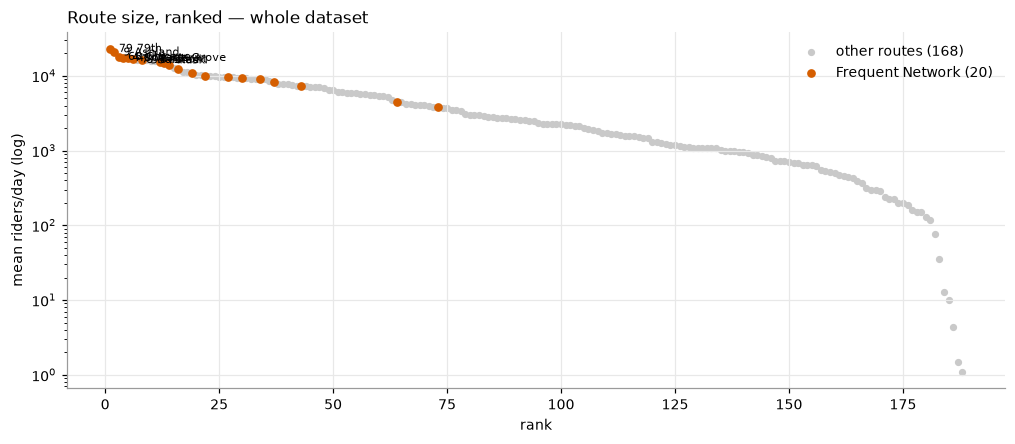

top 20 routes carry 37% of mean daily boardings; top 50 carry 68%


In [13]:
FREQ_SET = set(FREQ)
is_freq = inv.index.isin(FREQ_SET)
rank = np.arange(1, len(inv) + 1)

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.scatter(rank[~is_freq], inv['mean'][~is_freq], s=14, color=GRAY,
           label=f'other routes ({int((~is_freq).sum())})')
ax.scatter(rank[is_freq], inv['mean'][is_freq], s=22, color=ORANGE,
           label=f'Frequent Network ({int(is_freq.sum())})', zorder=3)
for r in inv.index[:8]:                                    # label the eight largest
    ax.annotate(f'{r} {inv.loc[r, "name"]}', (rank[inv.index.get_loc(r)], inv.loc[r, 'mean']),
                xytext=(6, 0), textcoords='offset points', fontsize=7, va='center')
ax.set_yscale('log')
ax.set_xlabel('rank'); ax.set_ylabel('mean riders/day (log)')
ax.set_title('Route size, ranked — whole dataset', loc='left', fontsize=11)
ax.legend(frameon=False, loc='upper right')
plt.show()

share = inv['mean'].sort_values(ascending=False).cumsum() / inv['mean'].sum()
print(f'top 20 routes carry {share.iloc[19]:.0%} of mean daily boardings; '
      f'top 50 carry {share.iloc[49]:.0%}')

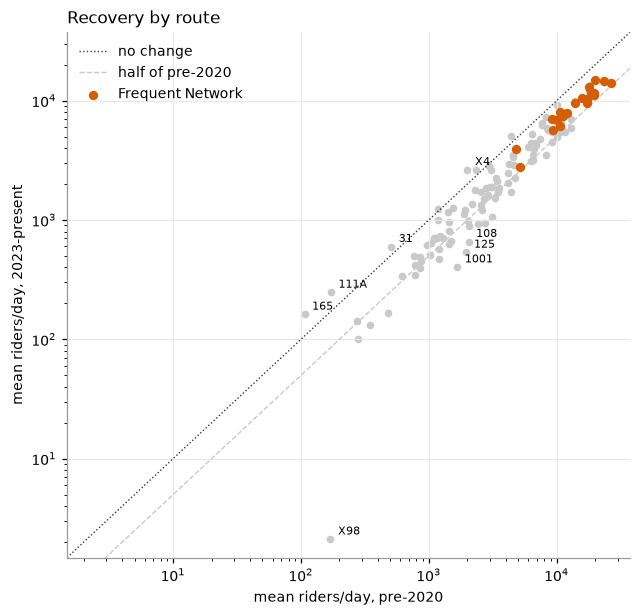

routes above pre-2020 level : 7 of 129
median recovery ratio       : 0.62

strongest and weakest:
                              name      pre      now  ratio
route                                                      
165                      West 65th   106.65   162.20   1.52
111A               Pullman Shuttle   171.40   247.89   1.45
X4           Cottage Grove Express  2005.95  2642.67   1.32
31                            31st   507.25   598.57   1.18
157           Streeterville/Taylor  4356.17  5060.37   1.16
X98                   Avon Express   170.19     2.12   0.01
1001   Shuttle/Special Event Route  1670.04   403.64   0.24
125            Water Tower Express  1968.08   536.47   0.27
108                   Halsted/95th  2047.08   659.60   0.32
1        Bronzeville/Union Station  3123.42  1064.02   0.34


In [14]:
# Recovery: pre-2020 mean against 2023-present mean, per route.
rec = pd.DataFrame({'pre': per_era[('mean', 'pre-2020')],
                    'now': per_era[('mean', '2023-present')],
                    'name': inv.name}).dropna(subset=['pre', 'now'])
rec['ratio'] = rec.now / rec.pre
freq_mask = rec.index.isin(FREQ_SET)

fig, ax = plt.subplots(figsize=(6.6, 6.2))
lims = [rec[['pre', 'now']].to_numpy().min() * 0.7, rec[['pre', 'now']].to_numpy().max() * 1.4]
ax.plot(lims, lims, color=INK, lw=0.9, ls=':', label='no change')
ax.plot(lims, [v * 0.5 for v in lims], color=GRAY, lw=0.9, ls='--', label='half of pre-2020')
ax.scatter(rec.pre[~freq_mask], rec.now[~freq_mask], s=16, color=GRAY)
ax.scatter(rec.pre[freq_mask], rec.now[freq_mask], s=26, color=ORANGE, zorder=3,
           label='Frequent Network')
for r in rec.ratio.nlargest(4).index.union(rec.ratio.nsmallest(4).index):
    ax.annotate(r, (rec.loc[r, 'pre'], rec.loc[r, 'now']), xytext=(5, 3),
                textcoords='offset points', fontsize=7)
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('mean riders/day, pre-2020'); ax.set_ylabel('mean riders/day, 2023-present')
ax.set_title('Recovery by route', loc='left', fontsize=11)
ax.legend(frameon=False, loc='upper left')
plt.show()

print(f'routes above pre-2020 level : {int((rec.ratio > 1).sum())} of {len(rec)}')
print(f'median recovery ratio       : {rec.ratio.median():.2f}')
print('\nstrongest and weakest:')
print(pd.concat([rec.nlargest(5, "ratio"), rec.nsmallest(5, "ratio")])
        [['name', 'pre', 'now', 'ratio']].round(2).to_string())

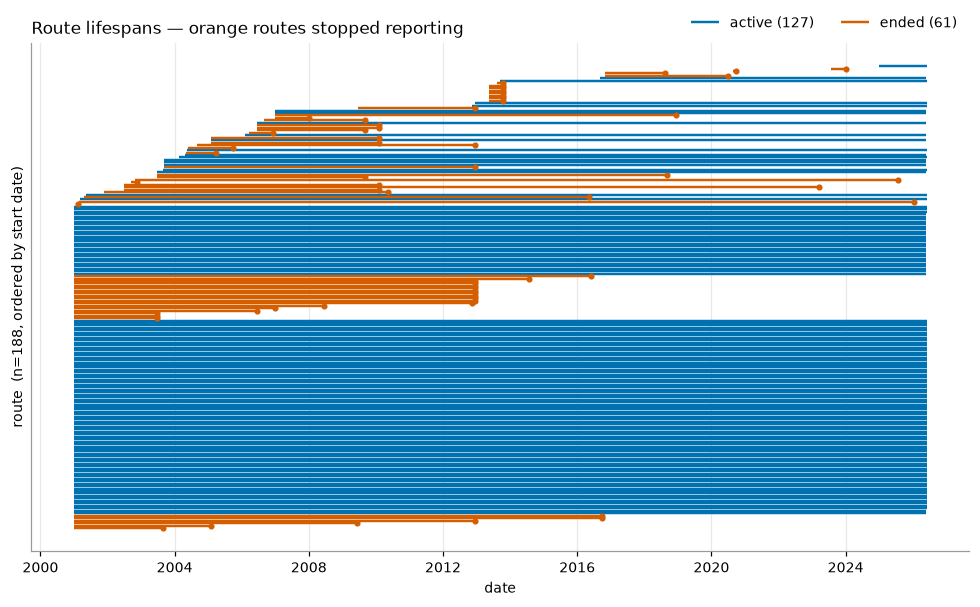

the 61 routes that stopped reporting, largest first:
                                name    first     last  riders/day
route                                                             
14                   Jeffery Express  2001-01  2012-11     10149.0
R95    95th-Garfield Express Shuttle  2013-05  2013-10      9512.0
1002             Special Event Route  2006-03  2006-12      7207.0
R63           Dan Ryan Local Shuttle  2013-05  2013-10      6548.0
145          Wilson/Michigan Express  2001-01  2012-12      5823.0
X54                   Cicero Express  2006-06  2010-02      5337.0
27                     South Deering  2001-01  2003-08      4721.0
95E                        93rd-95th  2001-01  2016-09      4402.0
95W                        West 95th  2001-01  2016-09      3896.0
R79    79th-Garfield Express Shuttle  2013-05  2013-10      3517.0
X28             Stony Island Express  2004-08  2012-12      3341.0
X80              Irving Park Express  2002-06  2010-02      2780.0
R87    87

In [15]:
# When each route ran. Sorted by start then end date, so cuts show up as a diagonal.
span = (d.groupby('route').date.agg(['min', 'max'])
          .join(inv[['status', 'mean', 'name']])
          .sort_values(['min', 'max']))
ended = span.status != 'active'

fig, ax = plt.subplots(figsize=(11, 6.0))
y = np.arange(len(span))
ax.hlines(y[~ended], span['min'][~ended], span['max'][~ended], color=BLUE, lw=1.6,
          label=f'active ({int((~ended).sum())})')
ax.hlines(y[ended], span['min'][ended], span['max'][ended], color=ORANGE, lw=1.6,
          label=f'ended ({int(ended.sum())})')
ax.scatter(span['max'][ended], y[ended], s=9, color=ORANGE, zorder=3)

ax.set_yticks([]); ax.set_ylabel(f'route  (n={len(span)}, ordered by start date)')
ax.set_xlabel('date')
ax.set_title('Route lifespans — orange routes stopped reporting', loc='left', fontsize=11)
ax.legend(frameon=False, loc='lower right', bbox_to_anchor=(1, 1.0), ncol=2)
plt.show()

print(f'the {int(ended.sum())} routes that stopped reporting, largest first:')
print(span[ended].nlargest(20, 'mean')[['name', 'min', 'max', 'mean']]
        .assign(min=lambda t: t['min'].dt.strftime('%Y-%m'),
                max=lambda t: t['max'].dt.strftime('%Y-%m'))
        .rename(columns={'min': 'first', 'max': 'last', 'mean': 'riders/day'})
        .round(0).to_string())
print(f'(showing 20 of {int(ended.sum())})')

## 4. Ridership by day of week

Three views, because "by day of week" means different things at different scales:

- **(a)** absolute mean rides per day, one line per year — dominated by the level change.
- **(b)** the same lines divided by each year's own mean, which is the test of whether the
  *shape* is stable year to year.
- **(c)** the spread within a single recent year, so the shape in (b) can be read against how
  much an individual day actually moves.

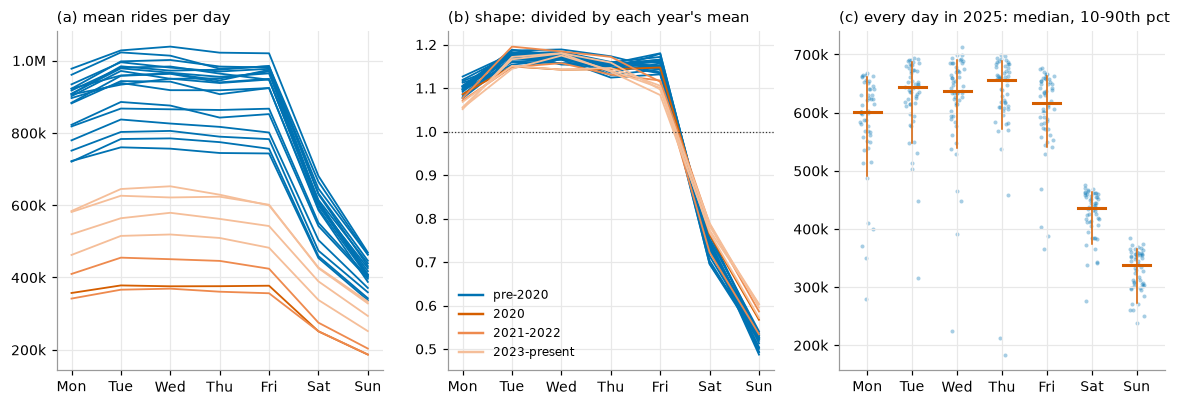

In [16]:
day = d.groupby('date', as_index=False).rides.sum()
day['dow']  = day.date.dt.dayofweek
day['year'] = day.date.dt.year
day['era']  = day.year.map(era)

by_yr = day.pivot_table(index='year', columns='dow', values='rides', aggfunc='mean')
shape = by_yr.div(by_yr.mean(axis=1), axis=0)      # each year normalised by its own mean
YR = 2025                                          # last complete calendar year

fig, axes = plt.subplots(1, 3, figsize=(13, 4.0))

for yr in by_yr.index:
    col = ERA_COLOR[era(yr)]
    axes[0].plot(range(7), by_yr.loc[yr], color=col, lw=1.2)
    axes[1].plot(range(7), shape.loc[yr], color=col, lw=1.2)

axes[0].set_title('(a) mean rides per day', loc='left', fontsize=10)
axes[0].yaxis.set_major_formatter(fmt_riders)
axes[1].set_title("(b) shape: divided by each year's mean", loc='left', fontsize=10)
axes[1].axhline(1, color=INK, lw=0.8, ls=':')
axes[1].legend(handles=[Line2D([], [], color=ERA_COLOR[n], lw=1.6, label=n) for n in ERA_ORDER],
               frameon=False, fontsize=8, loc='lower left')

sub = day[day.year == YR]
for i in range(7):
    v = sub.loc[sub.dow == i, 'rides']
    axes[2].scatter(i + np.random.uniform(-.16, .16, len(v)), v,
                    s=7, color=BLUE, alpha=0.35, linewidths=0)
    lo, mid, hi = np.percentile(v, [10, 50, 90])
    axes[2].plot([i - .3, i + .3], [mid, mid], color=ORANGE, lw=2, zorder=3)
    axes[2].plot([i, i], [lo, hi], color=ORANGE, lw=1, zorder=3)
axes[2].set_title(f'(c) every day in {YR}: median, 10-90th pct', loc='left', fontsize=10)
axes[2].yaxis.set_major_formatter(fmt_riders)

for ax in axes:
    ax.set_xticks(range(7)); ax.set_xticklabels(DOW)
plt.show()

**On the statistic.** Max-minus-min across years is a poor summary — it is decided by whichever
single year is most extreme, which here is 2020. Standard deviation and inter-quartile range
across years are reported instead, and separately by era, so a genuinely stable shape can be
told apart from one held together by averaging.

In [17]:
def spread(frame):
    """Across-year spread of the normalised day-of-week shape."""
    return pd.DataFrame({
        'std':     frame.std(),
        'IQR':     frame.quantile(.75) - frame.quantile(.25),
        'max-min': frame.max() - frame.min(),
    }).rename(index=lambda i: DOW[i]).T

print('all years (2001-2026)')
print(spread(shape).round(3).to_string())

for name in ERA_ORDER:
    yrs = [y for y in shape.index if era(y) == name]
    print(f'\n{name}  (n={len(yrs)} years)')
    print('  single year - no across-year spread defined' if len(yrs) < 2
          else spread(shape.loc[yrs]).round(3).to_string())

all years (2001-2026)
dow        Mon    Tue    Wed    Thu    Fri    Sat    Sun
std      0.020  0.014  0.013  0.012  0.026  0.026  0.034
IQR      0.026  0.020  0.021  0.013  0.029  0.033  0.025
max-min  0.075  0.051  0.047  0.049  0.096  0.094  0.116

pre-2020  (n=19 years)
dow        Mon    Tue    Wed    Thu    Fri    Sat    Sun
std      0.013  0.012  0.010  0.011  0.014  0.020  0.016
IQR      0.010  0.014  0.015  0.010  0.019  0.014  0.023
max-min  0.050  0.042  0.035  0.049  0.048  0.069  0.053

2020  (n=1 years)
  single year - no across-year spread defined

2021-2022  (n=2 years)
dow        Mon    Tue    Wed    Thu    Fri    Sat    Sun
std      0.004  0.033  0.019  0.029  0.002  0.046  0.037
IQR      0.003  0.024  0.013  0.020  0.001  0.033  0.026
max-min  0.005  0.047  0.027  0.041  0.003  0.065  0.052

2023-present  (n=4 years)
dow        Mon    Tue    Wed    Thu    Fri    Sat    Sun
std      0.007  0.013  0.018  0.009  0.009  0.010  0.015
IQR      0.005  0.018  0.013  0.010  0.0

## 5. Holidays

`daytype` is CTA's own label for which schedule ran: `W` weekday, `A` Saturday, `U` Sunday.
The true day of week comes from `date`. **A date whose label disagrees with its actual day of
week is a CTA-designated holiday** — a Monday run on a Sunday schedule.

Detecting them this way gives CTA's *operational* holiday list, which is the one that matters
for ridership. Names then come from `pandas`' `USFederalHolidayCalendar`, which also tells us
which federal holidays CTA does **not** treat as holidays.

In [18]:
# Do all routes agree on the daytype for a given date?
lab = d.groupby('date').daytype.agg(n='nunique', label='first')
print(f'dates where routes disagree on daytype : {int((lab.n > 1).sum()):,}')

cal = lab.reset_index()[['date', 'label']]
cal['dow']      = cal.date.dt.dayofweek
cal['expected'] = np.where(cal.dow <= 4, 'W', np.where(cal.dow == 5, 'A', 'U'))
cal['holiday']  = cal.label != cal.expected

print(f'dates total                            : {len(cal):,}')
print(f'dates flagged as holiday               : {int(cal.holiday.sum()):,}')
print(f'  weekday run on a Sunday schedule     : '
      f'{int(((cal.dow <= 4) & (cal.label == "U")).sum()):,}')
print(f'  weekday run on a Saturday schedule   : '
      f'{int(((cal.dow <= 4) & (cal.label == "A")).sum()):,}')
print(f'  weekend date NOT on its own schedule : '
      f'{int(((cal.dow >= 5) & cal.holiday).sum()):,}')

h = cal[cal.holiday].copy()

# Weekend dates that did not run their own schedule -- odd enough to look at individually.
odd = h[h.dow >= 5]
print(f'\nweekend dates on an unexpected schedule ({len(odd)}):')
print(odd[['date', 'label', 'expected']].to_string(index=False))

dates where routes disagree on daytype : 0
dates total                            : 9,282
dates flagged as holiday               : 152
  weekday run on a Sunday schedule     : 148
  weekday run on a Saturday schedule   : 0
  weekend date NOT on its own schedule : 4

weekend dates on an unexpected schedule (4):
      date label expected
2004-12-25     U        A
2005-01-01     U        A
2010-12-25     U        A
2011-01-01     U        A


In [19]:
from pandas.tseries.holiday import USFederalHolidayCalendar

# Look the names up rather than inferring them from calendar position. The calendar
# already applies the federal "observed" shift, which is what CTA follows too.
fed = USFederalHolidayCalendar().holidays(d.date.min(), d.date.max(), return_name=True)

h['name'] = h.date.map(fed)
print(f'matched on the federal OBSERVED date : {int(h.name.notna().sum())} of {len(h)}')

# The calendar lists the observed date, which shifts to the nearest weekday when a
# fixed-date holiday lands on a weekend. CTA sometimes runs the holiday schedule on the
# true date instead, so fall back to matching the actual month/day.
FIXED_DATE = {(1, 1):  "New Year's Day",
              (6, 19): 'Juneteenth National Independence Day',
              (7, 4):  'Independence Day',
              (11, 11): 'Veterans Day',
              (12, 25): 'Christmas Day'}

miss = h.name.isna()
if miss.any():
    h.loc[miss, 'name'] = [FIXED_DATE.get((t.month, t.day)) for t in h.loc[miss, 'date']]
    print(f'matched on the true (unshifted) date  : {int(miss.sum() - h.name.isna().sum())}')
    print(h.loc[miss, ['date', 'label', 'expected', 'name']].to_string(index=False))

still = h.name.isna()
print(f'\nstill unnamed: {int(still.sum())}')
if still.any():
    print(h.loc[still, ['date', 'label', 'expected']].to_string(index=False))
    h.loc[still, 'name'] = h.loc[still, 'date'].dt.strftime('%b %d') + ' (unnamed)'

print('\nflagged dates by name:')
print(h.name.value_counts().rename('dates').to_frame().to_string())

matched on the federal OBSERVED date : 148 of 152
matched on the true (unshifted) date  : 4
      date label expected           name
2004-12-25     U        A  Christmas Day
2005-01-01     U        A New Year's Day
2010-12-25     U        A  Christmas Day
2011-01-01     U        A New Year's Day

still unnamed: 0

flagged dates by name:
                  dates
name                   
New Year's Day       26
Memorial Day         26
Independence Day     25
Labor Day            25
Thanksgiving Day     25
Christmas Day        25


Which holidays count is not fixed in time — Juneteenth only became a federal holiday in 2021,
and `USFederalHolidayCalendar` reflects that. So the comparison below is **by year**, not a
single set difference, which would have hidden the change.

Only weekday occurrences are detectable: a holiday falling on a weekend already runs the
Saturday or Sunday schedule, so there is no label to disagree with.

In [20]:
fed_wd = (fed.rename('name').rename_axis('date').reset_index()
             .assign(year=lambda t: t.date.dt.year)
             .query('date.dt.dayofweek <= 4'))                 # weekday occurrences only

flagged = set(zip(h.name, h.date.dt.year))
fed_wd['cta'] = [(n, y) in flagged for n, y in zip(fed_wd.name, fed_wd.year)]

# Both columns count DATES, not years: 2021 holds two federal New Year's Days
# (Jan 1, and Dec 31 as the observance of 2022's), so a year count would not line up.
print((fed_wd.groupby('name')
             .agg(federal_weekday_dates=('cta', 'size'),
                  first=('year', 'min'), last=('year', 'max'),
                  cta_ran_holiday_schedule=('cta', 'sum'))
             .sort_values('cta_ran_holiday_schedule', ascending=False)
             .to_string()))

                                      federal_weekday_dates  first  last  cta_ran_holiday_schedule
name                                                                                              
Memorial Day                                             26   2001  2026                        26
New Year's Day                                           26   2001  2026                        26
Christmas Day                                            25   2001  2025                        25
Independence Day                                         25   2001  2025                        25
Labor Day                                                25   2001  2025                        25
Thanksgiving Day                                         25   2001  2025                        25
Birthday of Martin Luther King, Jr.                      26   2001  2026                         0
Columbus Day                                             25   2001  2025                         0
Juneteenth

In [21]:
# ---------------------------------------------------------------------------
# PROPOSED definition of "usual", flagged for review before anything is built on it:
#   usual(date) = median system ridership on the SAME day of week within +/- 4 weeks,
#                 excluding dates that are themselves flagged holidays.
# ---------------------------------------------------------------------------
sysday = day.set_index('date').rides
hol_dates = set(cal.loc[cal.holiday, 'date'])

def usual(dt, dow, span_days=28):
    win = sysday[(sysday.index >= dt - pd.Timedelta(days=span_days)) &
                 (sysday.index <= dt + pd.Timedelta(days=span_days))]
    win = win[(win.index.dayofweek == dow) & (~win.index.isin(hol_dates))]
    return (win.median(), len(win))

rows = []
for dt, dw, nm in zip(h.date, h.dow, h.name):
    u, n = usual(dt, dw)
    rows.append({'date': dt, 'name': nm, 'actual': sysday.get(dt, np.nan),
                 'usual': u, 'n_baseline': n})
hr = pd.DataFrame(rows)
hr['ratio'] = hr.actual / hr.usual

print(f'holiday dates scored          : {len(hr):,}')
print(f'  with no usable baseline     : {int(hr.usual.isna().sum()):,}')
print(f'  baseline dates used, median : {hr.n_baseline.median():.0f} (of 8 possible)')
print(f'  baseline built from < 4 days: {int((hr.n_baseline < 4).sum()):,}')

holiday dates scored          : 152
  with no usable baseline     : 0
  baseline dates used, median : 8 (of 8 possible)
  baseline built from < 4 days: 0


In [22]:
def box_with_points(ax, groups, labels, colour, ylabel, title, logy=False, names=None,
                    max_labels=3):
    """One box per group, individual observations jittered on top.

    If ``names`` is given (one array of labels per group), points outside the
    1.5*IQR fences are annotated, at most ``max_labels`` per side per group.
    Returns the outliers as a DataFrame so the full list can be printed.
    """
    ax.axhline(1, color=INK, lw=0.9, ls=':')
    bp = ax.boxplot(groups, positions=range(len(groups)), widths=0.6, showfliers=False,
                    patch_artist=True, medianprops={'color': ORANGE, 'lw': 1.8})
    for box in bp['boxes']:
        box.set(facecolor='#EFEFEF', edgecolor='#9A9A9A', lw=0.8)

    found = []
    for i, g in enumerate(groups):
        ax.scatter(i + np.random.uniform(-0.14, 0.14, len(g)), g,
                   s=10, color=colour, alpha=0.5, linewidths=0, zorder=3)
        if names is None:
            continue
        q1, q3 = np.percentile(g, [25, 75])
        fence = 1.5 * (q3 - q1)
        out = [(v, n) for v, n in zip(g, names[i]) if v < q1 - fence or v > q3 + fence]
        for v, n in out:
            found.append({'group': labels[i].split(chr(10))[0], 'name': n, 'value': v})
        low  = sorted([o for o in out if o[0] < q1], key=lambda t: t[0])[:max_labels]
        high = sorted([o for o in out if o[0] > q3], key=lambda t: -t[0])[:max_labels]
        for k, (v, n) in enumerate(low + high):
            ax.annotate(n, (i, v), xytext=(7, 6 if k % 2 else -6),
                        textcoords='offset points',
                        fontsize=7, color=INK, va='center')

    if logy:
        ax.set_yscale('log')
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc='left', fontsize=11)
    return pd.DataFrame(found)

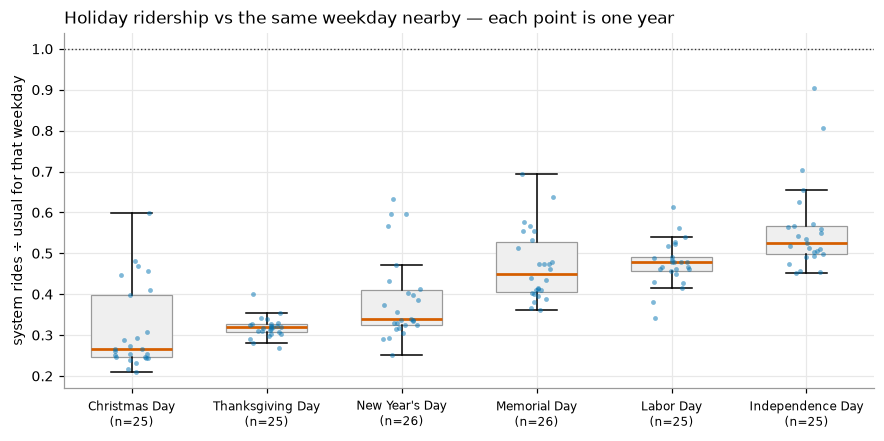

                  count  median    min    max
name                                         
Christmas Day        25   0.265  0.209  0.598
Independence Day     25   0.525  0.451  0.904
Labor Day            25   0.479  0.341  0.614
Memorial Day         26   0.450  0.360  0.694
New Year's Day       26   0.339  0.252  0.632
Thanksgiving Day     25   0.319  0.268  0.400


In [23]:
order  = hr.dropna(subset=['ratio']).groupby('name').ratio.median().sort_values().index
groups = [hr.loc[hr.name == nm, 'ratio'].dropna().to_numpy() for nm in order]

fig, ax = plt.subplots(figsize=(9.5, 4.2))
box_with_points(ax, groups, [f'{nm}\n(n={len(g)})' for nm, g in zip(order, groups)], BLUE,
                'system rides ÷ usual for that weekday',
                'Holiday ridership vs the same weekday nearby — each point is one year')
plt.show()

print(hr.groupby('name').ratio.agg(['count', 'median', 'min', 'max']).round(3).to_string())

### Does the holiday effect depend on the route?

Same ratio, computed per route instead of system-wide, pooled across all years. A route whose
box sits well above the system median is one where the holiday matters less — or where the
holiday itself generates trips.

In [24]:
rt = d.pivot_table(index='date', columns='route', values='rides', aggfunc='sum')

ratios, base_size = [], []
for dt, dw, nm in zip(h.date, h.dow, h.name):
    win = rt[(rt.index.dayofweek == dw) & ~rt.index.isin(hol_dates) &
             (rt.index >= dt - pd.Timedelta(days=28)) & (rt.index <= dt + pd.Timedelta(days=28))]
    base = win.median()
    ratios.append((rt.loc[dt] / base).replace([np.inf, -np.inf], np.nan).rename((nm, dt)))
    base_size.append(base.rename((nm, dt)))

pr   = pd.DataFrame(ratios)                       # (holiday, date) x route
base = pd.DataFrame(base_size)
print(f'route x holiday ratios computed : {int(pr.notna().sum().sum()):,}')
print(f'  ratio > 3 (route grew 3x+)    : {int((pr > 3).sum().sum()):,}')
print(f'  of those, usual < 100 rides/day: {int(((pr > 3) & (base < 100)).sum().sum()):,}')
print('\nExtreme ratios come from routes with a tiny baseline, so nothing is dropped —')
print('the axis below is log-scaled instead, and every route is shown.')

route x holiday ratios computed : 13,277
  ratio > 3 (route grew 3x+)    : 22
  of those, usual < 100 rides/day: 17

Extreme ratios come from routes with a tiny baseline, so nothing is dropped —
the axis below is log-scaled instead, and every route is shown.


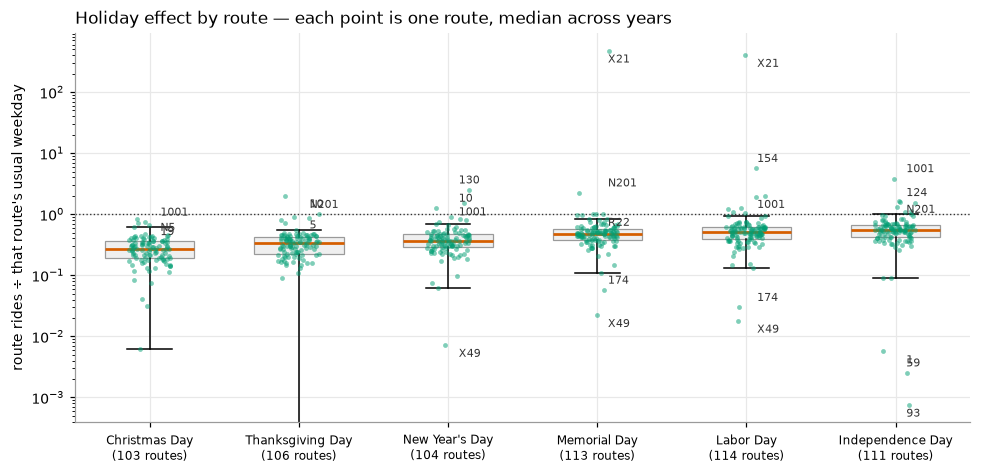

routes outside the 1.5xIQR fences: 48 (plot labels at most 4 per side per holiday)


,group,name,value
0,Christmas Day,5,0.669
1,Christmas Day,19,0.712
2,Christmas Day,1001,0.744
3,Christmas Day,N5,0.836
4,Independence Day,93,0.001
5,Independence Day,59,0.003
6,Independence Day,1,0.006
7,Independence Day,10,1.083
8,Independence Day,5,1.107
9,Independence Day,R22,1.309


In [25]:
med  = pr.groupby(level=0).median()               # holiday x route, median across years
keep = [nm for nm in order if nm in med.index]
groups = [med.loc[nm].dropna() for nm in keep]

fig, ax = plt.subplots(figsize=(10.5, 4.6))
outliers = box_with_points(
    ax, [g.to_numpy() for g in groups],
    [f'{nm}\n({len(g)} routes)' for nm, g in zip(keep, groups)], GREEN,
    "route rides ÷ that route's usual weekday",
    'Holiday effect by route — each point is one route, median across years',
    logy=True, names=[g.index.to_numpy() for g in groups])
plt.show()

print(f'routes outside the 1.5xIQR fences: {len(outliers)} '
      f'(plot labels at most 4 per side per holiday)')
with pd.option_context('display.max_rows', None):
    display(outliers.sort_values(['group', 'value']).reset_index(drop=True).round(3))

## Where this leaves us

Read the outputs above before anything gets built on them. Open questions carried forward:

1. The `usual` definition in §5 is a proposal, not an agreed choice.
2. Corridor grouping is untouched — §3 highlights route labels only.
3. Whether holiday weeks should be marked on the weekly series in §2 depends on how large the
   holiday effect in §5 turns out to be.